# NAVYA — Hyperparameter Tuning

This notebook runs bounded, group-aware searches for strong tree/boosting candidates and optionally SVR. No test woman is loaded into any fit or CV score.

## 1. Load only training women and define group-aware CV

`GroupKFold` makes each fold hold out complete women, preventing adjacent longitudinal windows from leaking across cross-validation folds.

In [1]:
from pathlib import Path
import json, time
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.svm import SVR
from xgboost import XGBRegressor

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
df = pd.read_csv(ROOT / "processed_data" / "model_ready_dataset.csv")
women = np.random.RandomState(42).permutation(np.sort(df.woman_id.unique()))
train = df[df.woman_id.isin(women[:800])]
X, y, g = train[FEATURES], train.next_cycle_length_days, train.woman_id
assert X.select_dtypes(exclude=np.number).empty, 'All model inputs must be numeric before median imputation.'
display(X.dtypes.rename('dtype').to_frame())
cv = GroupKFold(n_splits=4)
print("Training rows/women:", len(train), g.nunique())

,dtype
age_years,float64
menarche_age,float64
height_cm,float64
weight_kg,float64
bmi,float64
sleep_hours,float64
stress_level,int64
exercise_frequency,int64
uses_medication_or_contraceptive,float64
prev_cycle_1,int64


Training rows/women: 16000 800


## 2. Define bounded searches

The spaces are deliberately modest for repeatability. `RandomizedSearchCV` evaluates a reproducible bounded sample of 12 parameter combinations for each candidate; it is not presented as an exhaustive grid search. Each candidate has a pipeline, so every CV fold learns its own median imputer (and scaler for SVR).

In [2]:
def tree(m):
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", m)])


def scaled(m):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", m),
        ]
    )


searches = {
    "GradientBoostingRegressor": (
        tree(GradientBoostingRegressor(random_state=42)),
        {
            "model__n_estimators": [100, 150, 200, 250, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
            "model__min_samples_leaf": [1, 3, 5],
        },
    ),
    "RandomForestRegressor": (
        tree(RandomForestRegressor(random_state=42, n_jobs=-1)),
        {
            "model__n_estimators": [200, 350],
            "model__max_depth": [None, 8, 14],
            "model__min_samples_leaf": [1, 2, 5],
            "model__max_features": [0.7, 1.0],
        },
    ),
    "HistGradientBoostingRegressor": (
        tree(HistGradientBoostingRegressor(random_state=42)),
        {
            "model__learning_rate": [0.03, 0.06, 0.1],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0, 0.1, 1],
            "model__max_iter": [150, 250],
        },
    ),
    "XGBRegressor": (
        tree(XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)),
        {
            "model__n_estimators": [150, 250, 350],
            "model__max_depth": [2, 3, 4],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.7, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 1.0],
        },
    ),
    "SVR": (
        scaled(SVR()),
        {
            "model__C": [0.3, 1, 3, 10],
            "model__epsilon": [0.05, 0.1, 0.25],
            "model__gamma": ["scale", 0.03, 0.1],
        },
    ),
}
print("Candidates:", list(searches))

Candidates: ['GradientBoostingRegressor', 'RandomForestRegressor', 'HistGradientBoostingRegressor', 'XGBRegressor', 'SVR']


## 3. Fit searches and record CV MAE

`neg_mean_absolute_error` is maximized by scikit-learn, then converted back to the intuitive positive MAE for reporting.

In [3]:
records = []
tuned_dir = ROOT / "results" / "tuning"
tuned_dir.mkdir(parents=True, exist_ok=True)
for name, (pipe, space) in searches.items():
    started = time.perf_counter()
    search = RandomizedSearchCV(
        pipe,
        space,
        n_iter=min(12, np.prod([len(v) for v in space.values()])),
        scoring="neg_mean_absolute_error",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search.fit(X, y, groups=g)
    rec = {
        "model": name,
        "best_cv_mae": -search.best_score_,
        "runtime_seconds": time.perf_counter() - started,
        "best_params": search.best_params_,
    }
    records.append(rec)
    print(name, rec["best_cv_mae"], rec["best_params"])
leaderboard = pd.DataFrame(records).sort_values("best_cv_mae").reset_index(drop=True)
display(leaderboard[["model", "best_cv_mae", "runtime_seconds", "best_params"]])
leaderboard.to_csv(tuned_dir / "tuning_leaderboard.csv", index=False)
best = leaderboard.iloc[0].to_dict()
best["best_params"] = {
    k: v.item() if hasattr(v, "item") else v for k, v in best["best_params"].items()
}
with open(tuned_dir / "best_tuned_model.json", "w") as f:
    json.dump(best, f, indent=2)
print("Selected tuned model:", best["model"])

GradientBoostingRegressor 1.2372808533336077 {'model__n_estimators': 100, 'model__min_samples_leaf': 3, 'model__max_depth': 3, 'model__learning_rate': 0.1}
RandomForestRegressor 1.240400221982542 {'model__n_estimators': 350, 'model__min_samples_leaf': 5, 'model__max_features': 0.7, 'model__max_depth': 8}
HistGradientBoostingRegressor 1.237590879681463 {'model__max_leaf_nodes': 15, 'model__max_iter': 150, 'model__learning_rate': 0.1, 'model__l2_regularization': 1}
XGBRegressor 1.2334621667861938 {'model__subsample': 0.7, 'model__n_estimators': 250, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
SVR 1.268273615204376 {'model__gamma': 0.03, 'model__epsilon': 0.25, 'model__C': 1}


,model,best_cv_mae,runtime_seconds,best_params
0,XGBRegressor,1.233462,2.531653,"{'model__subsample': 0.7, 'model__n_estimators..."
1,GradientBoostingRegressor,1.237281,26.606360,"{'model__n_estimators': 100, 'model__min_sampl..."
2,HistGradientBoostingRegressor,1.237591,4.668918,"{'model__max_leaf_nodes': 15, 'model__max_iter..."
3,RandomForestRegressor,1.240400,47.579744,"{'model__n_estimators': 350, 'model__min_sampl..."
4,SVR,1.268274,95.857385,"{'model__gamma': 0.03, 'model__epsilon': 0.25,..."


Selected tuned model: XGBRegressor


## 4. Tuning leaderboard visualisation

This chart compares the best group-CV MAE for every tuned model and shows runtime separately, making the accuracy-versus-compute trade-off clear.

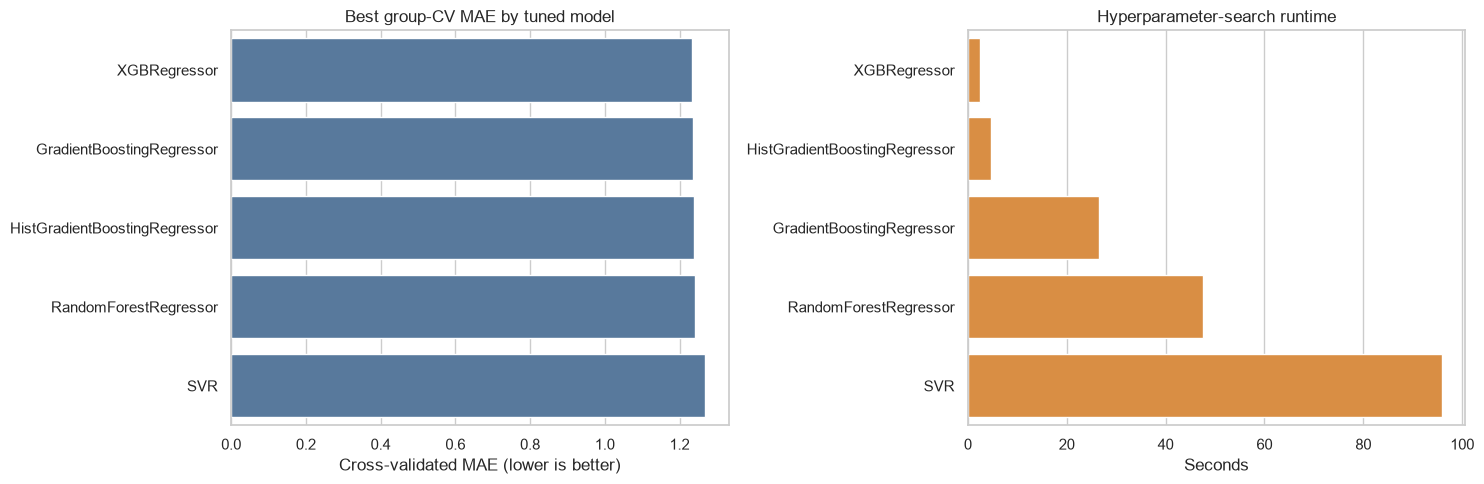

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_board = leaderboard.sort_values("best_cv_mae")
sns.barplot(data=plot_board, y="model", x="best_cv_mae", ax=axes[0], color="#4C78A8")
axes[0].set(
    title="Best group-CV MAE by tuned model",
    xlabel="Cross-validated MAE (lower is better)",
    ylabel="",
)
sns.barplot(
    data=plot_board.sort_values("runtime_seconds"),
    y="model",
    x="runtime_seconds",
    ax=axes[1],
    color="#F28E2B",
)
axes[1].set(title="Hyperparameter-search runtime", xlabel="Seconds", ylabel="")
plt.tight_layout()
plt.show()
plt.savefig(
    tuned_dir / "tuning_leaderboard_visualisation.png", dpi=180, bbox_inches="tight"
)

,model,best_cv_mae,C,colsample_bytree,epsilon,gamma,l2_regularization,learning_rate,max_depth,max_features,max_iter,max_leaf_nodes,min_samples_leaf,n_estimators,subsample
0,XGBRegressor,1.233500,nan,1.000000,nan,nan,nan,0.030000,2.000000,nan,nan,nan,nan,250.000000,0.700000
1,GradientBoostingRegressor,1.237300,nan,nan,nan,nan,nan,0.100000,3.000000,nan,nan,nan,3.000000,100.000000,nan
2,HistGradientBoostingRegressor,1.237600,nan,nan,nan,nan,1.000000,0.100000,nan,nan,150.000000,15.000000,nan,nan,nan
3,RandomForestRegressor,1.240400,nan,nan,nan,nan,nan,nan,8.000000,0.700000,nan,nan,5.000000,350.000000,nan
4,SVR,1.268300,1.000000,nan,0.250000,0.030000,nan,nan,nan,nan,nan,nan,nan,nan,nan


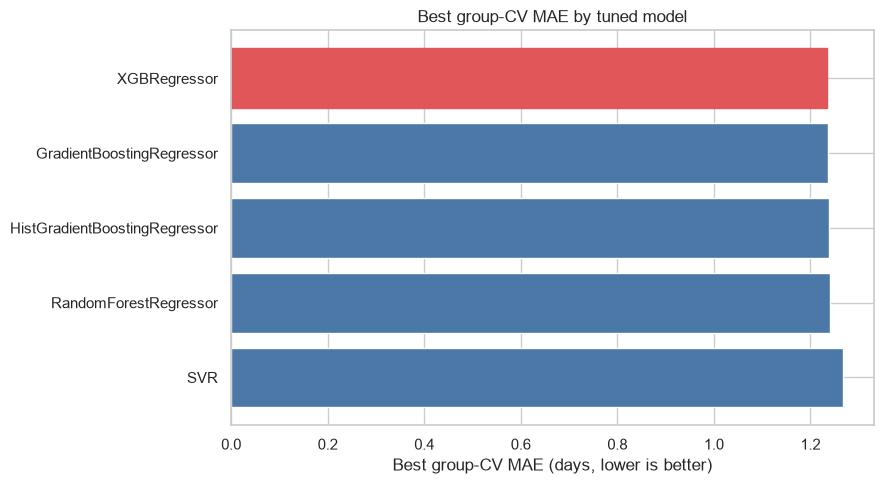

In [6]:
import ast
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
csv_path = ROOT / "results" / "tuning" / "tuning_leaderboard.csv"

if csv_path.exists():
    res = pd.read_csv(csv_path)
else:
    res = pd.DataFrame([
        {"model": "XGBRegressor", "best_cv_mae": 1.2334621667861938,
         "best_params": "{'model__subsample': 0.7, 'model__n_estimators': 250, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}"},
        {"model": "GradientBoostingRegressor", "best_cv_mae": 1.2372808533336077,
         "best_params": "{'model__n_estimators': 100, 'model__min_samples_leaf': 3, 'model__max_depth': 3, 'model__learning_rate': 0.1}"},
        {"model": "HistGradientBoostingRegressor", "best_cv_mae": 1.237590879681463,
         "best_params": "{'model__max_leaf_nodes': 15, 'model__max_iter': 150, 'model__learning_rate': 0.1, 'model__l2_regularization': 1}"},
        {"model": "RandomForestRegressor", "best_cv_mae": 1.240400221982542,
         "best_params": "{'model__n_estimators': 350, 'model__min_samples_leaf': 5, 'model__max_features': 0.7, 'model__max_depth': 8}"},
        {"model": "SVR", "best_cv_mae": 1.268273615204376,
         "best_params": "{'model__gamma': 0.03, 'model__epsilon': 0.25, 'model__C': 1}"},
    ])

# Parse the best_params strings into dicts.
def parse_params(s):
    d = ast.literal_eval(s) if isinstance(s, str) else dict(s)
    return {k.replace("model__", ""): v for k, v in d.items()}

res["params_dict"] = res["best_params"].apply(parse_params)
param_cols = sorted({k for d in res["params_dict"] for k in d})

# Build a wide table: one column per hyperparameter.
rows = []
for _, r in res.sort_values("best_cv_mae").iterrows():
    row = {"model": r["model"], "best_cv_mae": round(r["best_cv_mae"], 4)}
    row.update({k: r["params_dict"].get(k) for k in param_cols})
    rows.append(row)
table = pd.DataFrame(rows)

display(
    table.style
    .bar(subset=["best_cv_mae"], color="#4C78A8")
    .set_properties(subset=["model"], **{"font-weight": "bold"})
)

# Keep a horizontal bar chart of the MAE comparison too.
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(res["model"], res["best_cv_mae"], color="#4C78A8")
bars[0].set_color("#E15759")  # best (lowest) MAE
ax.set_xlabel("Best group-CV MAE (days, lower is better)")
ax.set_title("Best group-CV MAE by tuned model")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Observation

The saved tuning leaderboard identifies the lowest group-CV MAE candidate. Notebook 08 fits that locked choice on the training women and calibrates uncertainty on validation women; Notebook 09 then evaluates that unchanged calibrated model on the untouched test women once.